In [3]:
import tensorflow as tf
from tensorflow import keras

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
data=pd.read_csv('AirPassengers.csv')

In [6]:
data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [7]:
data.shape

(144, 2)

In [8]:
data['Month']=pd.to_datetime(data['Month'])

In [9]:
data.set_index('Month',inplace=True)

In [10]:
import matplotlib.pyplot as plt

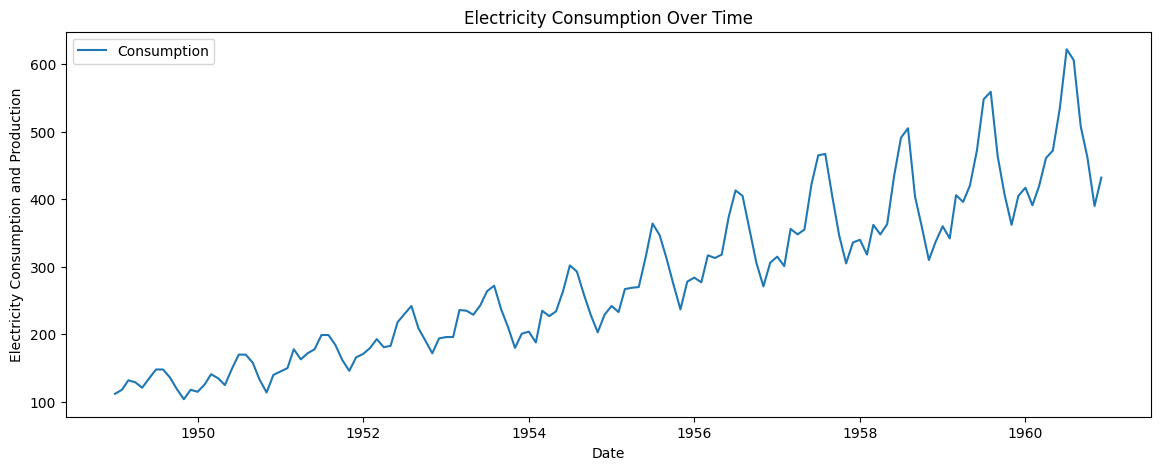

In [11]:
plt.figure(figsize=(14,5))
plt.plot(data.index,data,label='Consumption')

plt.xlabel("Date")
plt.ylabel("Electricity Consumption and Production")
plt.title("Electricity Consumption Over Time")
plt.legend()
plt.show()

In [12]:
data.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [13]:
import sys

print(sys.version)
print(sys.executable)

3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
C:\Users\Mcc\AppData\Local\Programs\Python\Python310\python.exe


In [14]:
pip show tensorflow

Name: tensorflow
Version: 2.21.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: c:\users\mcc\appdata\local\programs\python\python310\lib\site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, termcolor, typing_extensions, wrapt
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [15]:
dates=data.index

In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

In [17]:
scaled_data = scaler.fit_transform(data)

In [18]:
scaled_data

array([[0.01544402],
       [0.02702703],
       [0.05405405],
       [0.04826255],
       [0.03281853],
       [0.05984556],
       [0.08494208],
       [0.08494208],
       [0.06177606],
       [0.02895753],
       [0.        ],
       [0.02702703],
       [0.02123552],
       [0.04247104],
       [0.07142857],
       [0.05984556],
       [0.04054054],
       [0.08687259],
       [0.12741313],
       [0.12741313],
       [0.1042471 ],
       [0.05598456],
       [0.01930502],
       [0.06949807],
       [0.07915058],
       [0.08880309],
       [0.14285714],
       [0.11389961],
       [0.13127413],
       [0.14285714],
       [0.18339768],
       [0.18339768],
       [0.15444015],
       [0.11196911],
       [0.08108108],
       [0.11969112],
       [0.12934363],
       [0.14671815],
       [0.17181467],
       [0.14864865],
       [0.15250965],
       [0.22007722],
       [0.24324324],
       [0.26640927],
       [0.2027027 ],
       [0.16795367],
       [0.13127413],
       [0.173

In [19]:
type(scaled_data)

numpy.ndarray

In [20]:
data_scaled =scaled_data.reshape(-1, 1)

In [21]:
data_scaled.shape

(144, 1)

In [22]:
data_scaled

array([[0.01544402],
       [0.02702703],
       [0.05405405],
       [0.04826255],
       [0.03281853],
       [0.05984556],
       [0.08494208],
       [0.08494208],
       [0.06177606],
       [0.02895753],
       [0.        ],
       [0.02702703],
       [0.02123552],
       [0.04247104],
       [0.07142857],
       [0.05984556],
       [0.04054054],
       [0.08687259],
       [0.12741313],
       [0.12741313],
       [0.1042471 ],
       [0.05598456],
       [0.01930502],
       [0.06949807],
       [0.07915058],
       [0.08880309],
       [0.14285714],
       [0.11389961],
       [0.13127413],
       [0.14285714],
       [0.18339768],
       [0.18339768],
       [0.15444015],
       [0.11196911],
       [0.08108108],
       [0.11969112],
       [0.12934363],
       [0.14671815],
       [0.17181467],
       [0.14864865],
       [0.15250965],
       [0.22007722],
       [0.24324324],
       [0.26640927],
       [0.2027027 ],
       [0.16795367],
       [0.13127413],
       [0.173

In [23]:
import numpy as np
window = 24
X = [] 
y = []
for i in range(window, len(data_scaled)): 
    X.append(data_scaled[i-window:i]) 
    y.append(data_scaled[i]) 
X = np.array(X)
y = np.array(y)

In [24]:
X.shape

(120, 24, 1)

In [25]:
y.shape

(120, 1)

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization

In [68]:

# model = Sequential([
#     LSTM(16, input_shape=(24, 1)),
#     Dropout(0.1),
#     Dense(16, activation="relu"),
#     #Dense(8, activation="relu"),
#     Dense(1)
# ])
model = Sequential([
    LSTM(32, input_shape=(24, 1)),
    Dropout(0.1),
    Dense(16, activation="relu"),
    Dense(8,activation="relu"),
    Dense(1)
])

C:\Users\Mcc\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [69]:

from tensorflow.keras.optimizers import AdamW
optimizer = AdamW(
    learning_rate=0.001
)

model.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"]
)

In [70]:
window = 24

# Dates corresponding to y
dates = data.index[window:]

# Split positions
train_end = int(len(X) * 0.7)
val_end = int(len(X) * 0.85)

# Training
X_train = X[:train_end]
y_train = y[:train_end]
dates_train = dates[:train_end]

# Validation
X_val = X[train_end:val_end]
y_val = y[train_end:val_end]
dates_val = dates[train_end:val_end]

# Test
X_test = X[val_end:]
y_test = y[val_end:]
dates_test = dates[val_end:]

In [71]:
X_train.shape,y_train.shape,X_test.shape,y_test.shape,dates_train.shape,dates_test.shape

((84, 24, 1), (84, 1), (18, 24, 1), (18, 1), (84,), (18,))

In [72]:
dates_test

DatetimeIndex(['1959-07-01', '1959-08-01', '1959-09-01', '1959-10-01',
               '1959-11-01', '1959-12-01', '1960-01-01', '1960-02-01',
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', freq=None)

In [73]:
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5, #New LR=Old LR×0.5
    patience=15,
    min_lr=1e-6
)

#ReduceLROnPlateau is a learning-rate scheduler used during neural-network training. 
#It automatically reduces the learning rate when your model stops improving.


In [74]:
history = model.fit(
    X_train,
    y_train,
    epochs=300,
    batch_size=8,
    validation_data=(X_val, y_val),
    shuffle=False,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 0.0332 - mae: 0.1634 - val_loss: 0.0363 - val_mae: 0.1572 - learning_rate: 0.0010
Epoch 2/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0081 - mae: 0.0730 - val_loss: 0.0120 - val_mae: 0.0898 - learning_rate: 0.0010
Epoch 3/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0122 - mae: 0.0876 - val_loss: 0.0187 - val_mae: 0.0997 - learning_rate: 0.0010
Epoch 4/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0100 - mae: 0.0690 - val_loss: 0.0146 - val_mae: 0.0902 - learning_rate: 0.0010
Epoch 5/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0074 - mae: 0.0667 - val_loss: 0.0128 - val_mae: 0.0877 - learning_rate: 0.0010
Epoch 6/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0078 - mae: 0.0664 - val_loss: 0.0136 - val_mae: 0.0890 - learning_rate: 0.0010
Epoch 7/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0069 - mae: 0.0631 - val_loss: 0.0122 - val_mae: 0.0884 - learning_rate: 0.0010
Epoch 

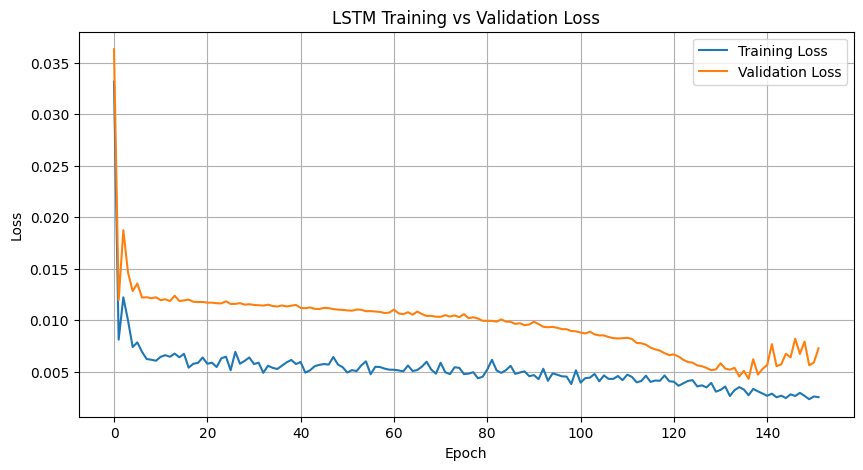

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [81]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


In [82]:
y_pred_actual = scaler.inverse_transform(y_pred)
y_test_actual = scaler.inverse_transform(y_test)

In [83]:
y_pred_actual.shape

(18, 1)

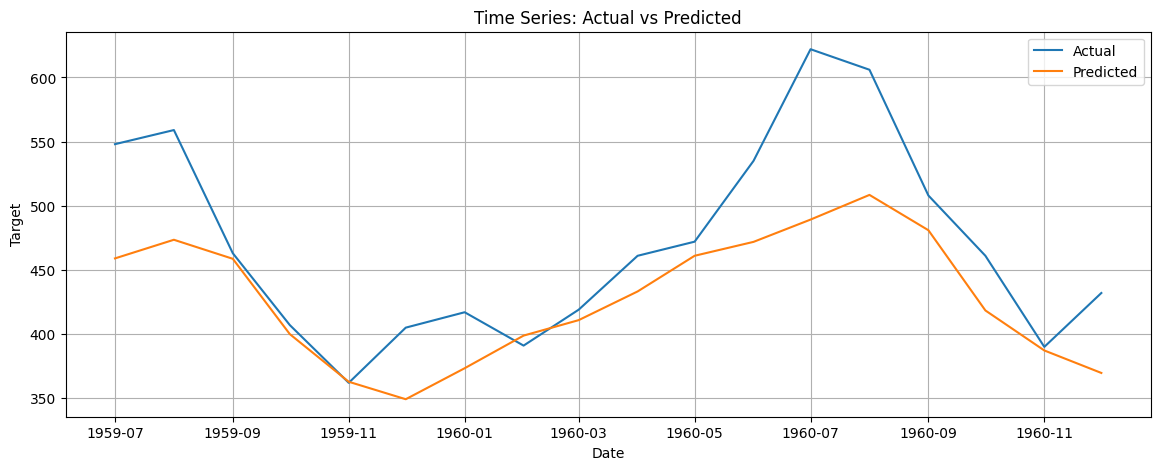

In [84]:

plt.figure(figsize=(14, 5))

plt.plot(dates_test,y_test_actual, label="Actual")
plt.plot(dates_test, y_pred_actual, label="Predicted")

plt.xlabel("Date")
plt.ylabel("Target")
plt.title("Time Series: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()

In [85]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(
    y_test_actual,
    y_pred_actual
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred_actual
    )
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 42.732057359483505
RMSE: 57.21231066933534


In [86]:
y_pred_actual

array([[458.96365],
       [473.49307],
       [458.65656],
       [399.94623],
       [362.81485],
       [349.20746],
       [373.3608 ],
       [398.79517],
       [410.8525 ],
       [433.20792],
       [461.01004],
       [471.84995],
       [489.22244],
       [508.45428],
       [480.92853],
       [418.38318],
       [387.2097 ],
       [369.68668]], dtype=float32)

In [87]:
last_sequence = data_scaled[-12:].copy()

future_predictions = []

for i in range(12):

    X_future = last_sequence.reshape(1, 12, 1)

    pred = model.predict(X_future, verbose=0)

    future_predictions.append(pred[0, 0])

    # Remove oldest month
    # and add the new prediction
    last_sequence = np.append(
        last_sequence[1:],
        pred[0]
    )

In [88]:
future_predictions = np.array(
    future_predictions
).reshape(-1, 1)

future_predictions = scaler.inverse_transform(
    future_predictions
)

In [89]:
print(future_predictions)

[[260.05597]
 [242.80261]
 [252.4948 ]
 [273.21042]
 [297.03058]
 [319.99707]
 [331.54013]
 [326.80606]
 [309.9877 ]
 [290.2996 ]
 [270.8475 ]
 [256.728  ]]


In [90]:
last_date = data.index[-1]

In [91]:
last_date

Timestamp('1960-12-01 00:00:00')

In [92]:
future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

In [93]:


future_df = pd.DataFrame({
    "Month": future_dates,
    "Predicted_Passengers": future_predictions.flatten()
})

print(future_df)

        Month  Predicted_Passengers
0  1961-01-01            260.055969
1  1961-02-01            242.802612
2  1961-03-01            252.494797
3  1961-04-01            273.210419
4  1961-05-01            297.030579
5  1961-06-01            319.997070
6  1961-07-01            331.540131
7  1961-08-01            326.806061
8  1961-09-01            309.987701
9  1961-10-01            290.299591
10 1961-11-01            270.847504
11 1961-12-01            256.727997


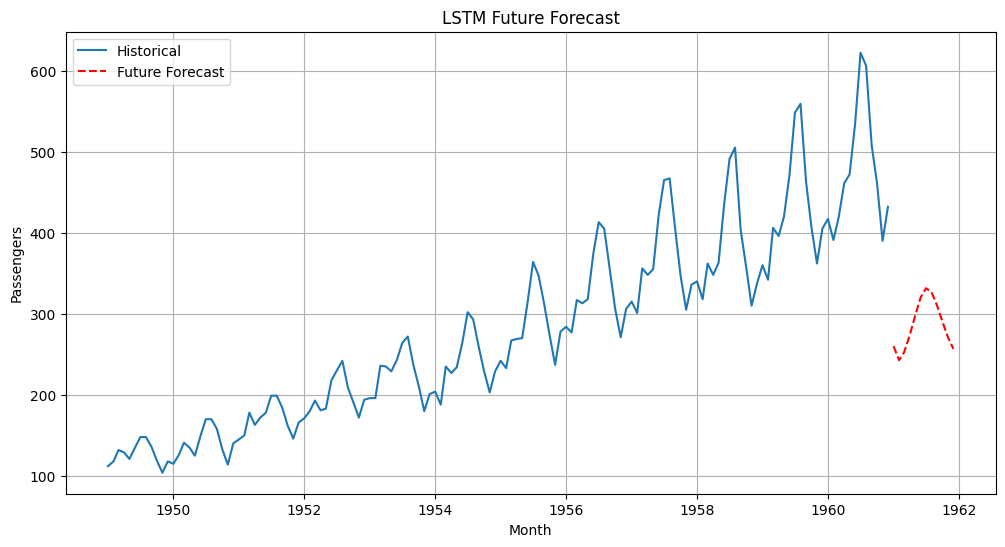

In [94]:
plt.figure(figsize=(12, 6))

plt.plot(
    data.index,
    data["#Passengers"],
    label="Historical"
)

plt.plot(
    future_df['Month'],
    future_df["Predicted_Passengers"],
    color="red",
    label="Future Forecast",
    linestyle='--'
)

plt.xlabel("Month")
plt.ylabel("Passengers")
plt.title("LSTM Future Forecast")
plt.legend()
plt.grid(True)

plt.show()